## 1.5: Data Analysis 📊

Now that we know that text, audio and images are represented as numbers, you might be wondering: what happens next? How do we obtain useful information from those numbers?

Let's analyse some representations of text, audio and images.

## 📜 Table of Contents

**1. Analysing Text 📚**

Understanding what useful statistical information we can get from text.

**2. Analysing Audio 🎵**

How audio signals are represented, and how we extract audio **features**.


**3. Analysing Images 🖼**

Processing Images to gain insights.

---

In [79]:
import os 
from collections import Counter

import IPython.display as ipd
import librosa
import matplotlib.pyplot as plt
import numpy as np
import skimage
from wordcloud import WordCloud, STOPWORDS


np.set_printoptions(suppress=True)

## 1. Analysing Text 📚
In the previous notebook we built a data pipeline for processing text, and understood how to create a vocabulary of tokens.

Now, how can we take advantage of that structure to learn more about a certain text? 

Let's consider the opening lines from Shakespeare's Romeo and Juliet.


In [1]:
shakespeare = """
Two households, both alike in dignity,
In fair Verona, where we lay our scene,
From ancient grudge break to new mutiny,
Where civil blood makes civil hands unclean.
From forth the fatal loins of these two foes
A pair of star-cross'd lovers take their life;
Whose misadventured piteous overthrows
Do with their death bury their parents' strife.
The fearful passage of their death-mark'd love,
And the continuance of their parents' rage,
Which, but their children's end, nought could remove,
Is now the two hours' traffic of our stage;
The which if you with patient ears attend,
What here shall miss, our toil shall strive to mend.
"""

As we learnt in the previous notebook, before performing any analysis, we need to create a vocabulary:

In [8]:
print(f"Original text (String):  '{shakespeare}'")

# turn all letters to lower case
shakespeare_lower = shakespeare.lower()

print(f"Lower-case text (String):  '{shakespeare_lower}'")

# replace newline characters with spaces
shakespeare_spaces = shakespeare_lower.replace("\n", " ")
# separate common punctuation marks from words by adding spaces around them
shakespeare_punctuation = shakespeare_spaces.replace(",", " , ")
shakespeare_punctuation = shakespeare_punctuation.replace(".", " . ")
shakespeare_punctuation = shakespeare_punctuation.replace("?", " ? ")
shakespeare_punctuation = shakespeare_punctuation.replace("!", " ! ")
shakespeare_punctuation = shakespeare_punctuation.replace('"', ' " ')
# split the text into a list of words
shakespeare_word_list = shakespeare_punctuation.split(" ")
# remove everything that is not a word (e.g., numbers, punctuation)
shakespeare_word_list = [w for w in shakespeare_word_list if any(ch.isalpha() for ch in w)]

print(f"Text sequence (List):  {shakespeare_word_list}")

# get the unique words
unique_words = sorted(set(shakespeare_word_list))
# build the vocabulary
vocabulary = {}
for i, word in enumerate(unique_words):
    vocabulary[word] = i

print(f"Vocabulary (Dict):         {vocabulary}")

Original text (String):  '
Two households, both alike in dignity,
In fair Verona, where we lay our scene,
From ancient grudge break to new mutiny,
Where civil blood makes civil hands unclean.
From forth the fatal loins of these two foes
A pair of star-cross'd lovers take their life;
Whose misadventured piteous overthrows
Do with their death bury their parents' strife.
The fearful passage of their death-mark'd love,
And the continuance of their parents' rage,
Which, but their children's end, nought could remove,
Is now the two hours' traffic of our stage;
The which if you with patient ears attend,
What here shall miss, our toil shall strive to mend.
'
Lower-case text (String):  '
two households, both alike in dignity,
in fair verona, where we lay our scene,
from ancient grudge break to new mutiny,
where civil blood makes civil hands unclean.
from forth the fatal loins of these two foes
a pair of star-cross'd lovers take their life;
whose misadventured piteous overthrows
do with their de

What's the size of our vocabulary?

In [9]:
print(f"Vocabulary size: {len(vocabulary)} unique words")
print(f"Total words: {len(shakespeare_word_list)}")

Vocabulary size: 80 unique words
Total words: 106


Let's check count how many times each word was used using the Counter class.

In [ ]:
word_counts = Counter(shakespeare_word_list)

print(word_counts)

Counter({'their': 6, 'the': 5, 'of': 5, 'two': 3, 'our': 3, 'in': 2, 'where': 2, 'from': 2, 'to': 2, 'civil': 2, 'with': 2, "parents'": 2, 'which': 2, 'shall': 2, 'households': 1, 'both': 1, 'alike': 1, 'dignity': 1, 'fair': 1, 'verona': 1, 'we': 1, 'lay': 1, 'scene': 1, 'ancient': 1, 'grudge': 1, 'break': 1, 'new': 1, 'mutiny': 1, 'blood': 1, 'makes': 1, 'hands': 1, 'unclean': 1, 'forth': 1, 'fatal': 1, 'loins': 1, 'these': 1, 'foes': 1, 'a': 1, 'pair': 1, "star-cross'd": 1, 'lovers': 1, 'take': 1, 'life;': 1, 'whose': 1, 'misadventured': 1, 'piteous': 1, 'overthrows': 1, 'do': 1, 'death': 1, 'bury': 1, 'strife': 1, 'fearful': 1, 'passage': 1, "death-mark'd": 1, 'love': 1, 'and': 1, 'continuance': 1, 'rage': 1, 'but': 1, "children's": 1, 'end': 1, 'nought': 1, 'could': 1, 'remove': 1, 'is': 1, 'now': 1, "hours'": 1, 'traffic': 1, 'stage;': 1, 'if': 1, 'you': 1, 'patient': 1, 'ears': 1, 'attend': 1, 'what': 1, 'here': 1, 'miss': 1, 'toil': 1, 'strive': 1, 'mend': 1})


As you can see, this is a Dictionary that cointains pairs of words and the count of how many times they appeared in the text.

We can use the following code to get the 10 most common words of the text:

In [58]:
print("Top 10 most common words:")
for word, count in word_counts.most_common(10):
    print(f"  {word}: {count}")

Top 10 most common words:
  their: 6
  the: 5
  of: 5
  two: 3
  our: 3
  in: 2
  where: 2
  from: 2
  to: 2
  civil: 2


This is great! However, it would be more interesting to analyse a longer text. What about trying with a whole book?

Let's analyse Charles Dicken's Oliver Twist.

In [80]:
# read file with book's text
text_file_path = os.path.join("media", "Dickens.txt")
with open(text_file_path, "r", encoding="utf-8") as f:
    dickens = f.read()

Let's create the vocabulary for the new text:

In [81]:
# turn all letters to lower case
dickens_lower = dickens.lower()

# replace newline characters with spaces
dickens_spaces = dickens_lower.replace("\n", " ")
# separate common punctuation marks from words by adding spaces around them
dickens_punctuation = dickens_spaces.replace(",", " , ")
dickens_punctuation = dickens_punctuation.replace(".", " . ")
dickens_punctuation = dickens_punctuation.replace("?", " ? ")
dickens_punctuation = dickens_punctuation.replace("!", " ! ")
dickens_punctuation = dickens_punctuation.replace('"', ' " ')
dickens_punctuation = dickens_punctuation.replace('“', ' “ ')

# split the text into a list of words
dickens_word_list = dickens_punctuation.split(" ")
# remove everything that is not a word (e.g., numbers, punctuation)
dickens_word_list = [w for w in dickens_word_list if any(ch.isalpha() for ch in w)]

# get the unique words
unique_words = sorted(set(dickens_word_list))
# build the vocabulary
vocabulary = {}
for i, word in enumerate(unique_words):
    vocabulary[word] = i

How many unique words do we have? How about the total number of words in the text?

In [82]:
print(f"Vocabulary size: {len(vocabulary)} unique words")
print(f"Total words: {len(dickens_word_list)}")

Vocabulary size: 13211 unique words
Total words: 158060


What are the most used words?

In [77]:
word_counts = Counter(dickens_word_list)
print("Top 50 most common words:")
for word, count in word_counts.most_common(50):
    print(f"  {word}: {count}")

Top 50 most common words:
  the: 9584
  and: 5348
  of: 3857
  to: 3855
  a: 3728
  he: 2388
  in: 2367
  his: 2351
  that: 1814
  was: 1773
  it: 1662
  i: 1609
  you: 1577
  with: 1566
  as: 1311
  said: 1223
  had: 1221
  for: 1137
  mr: 1076
  him: 1005
  at: 989
  on: 933
  which: 872
  this: 784
  not: 769
  by: 762
  her: 762
  be: 761
  have: 757
  oliver: 743
  but: 719
  is: 708
  they: 673
  from: 630
  all: 595
  if: 592
  no: 571
  me: 570
  so: 565
  were: 550
  she: 549
  my: 506
  who: 504
  or: 495
  when: 492
  very: 488
  what: 481
  upon: 477
  there: 477
  up: 468


The **frequency** of a word is the amount of times it appears in the text.

In [15]:
top_n = 50
top_common = word_counts.most_common(top_n)
words = [word for word, count in top_common]
frequencies = [count for word, count in top_common]

We can visualise how often each word is written by plotting a histogram of their frequencies:

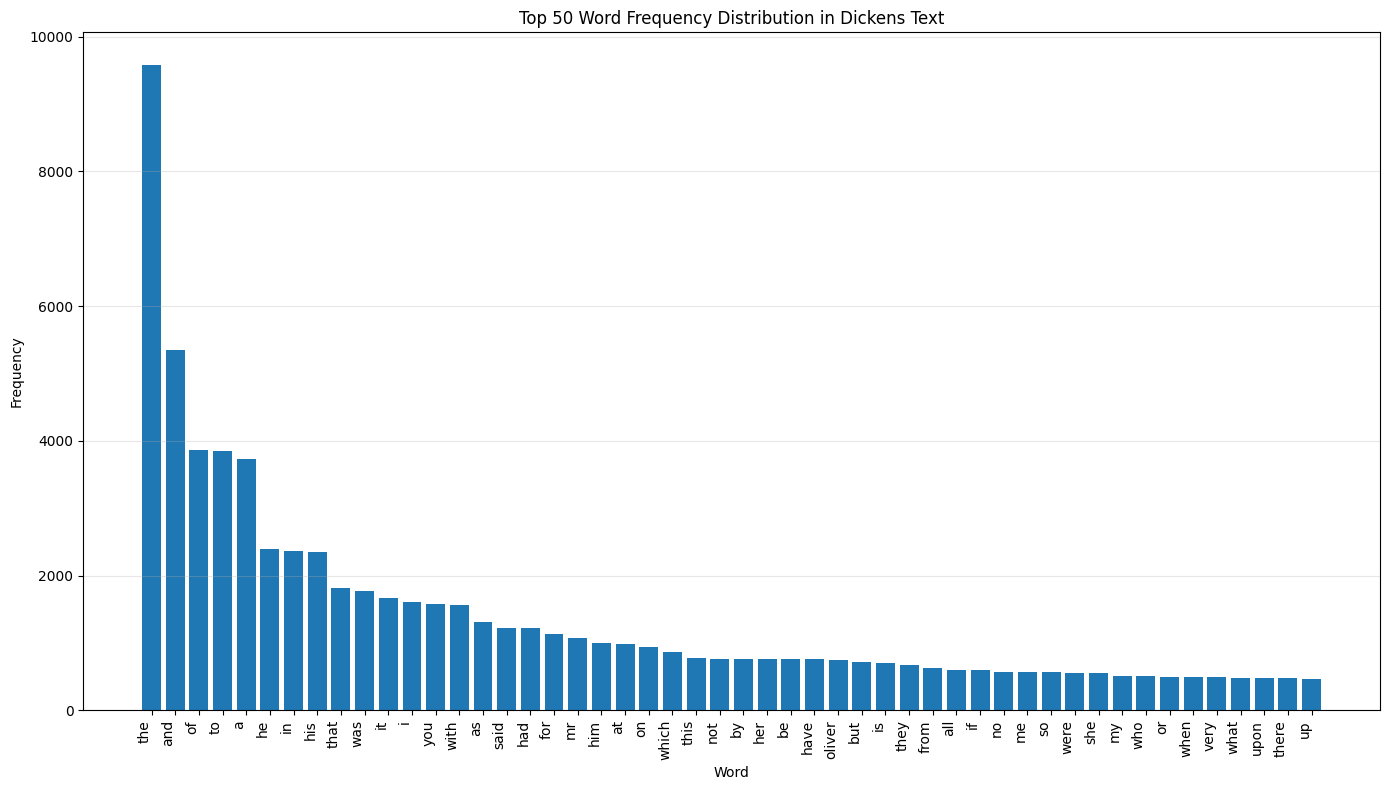

Most frequent word: 'their' appears 6 times
Number of words appearing only once: 66


In [ ]:
plt.figure(figsize=(14, 8))
plt.bar(range(len(frequencies)), frequencies)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Top 50 Word Frequency Distribution in Dickens Text')
plt.xticks(range(len(words)), words, rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Most frequent word: '{word_counts.most_common(1)[0][0]}' appears {word_counts.most_common(1)[0][1]} times")
print(f"Number of words appearing only once: {sum(1 for count in word_counts.values() if count == 1)}")

We can also visualise the most used words using a world cloud.

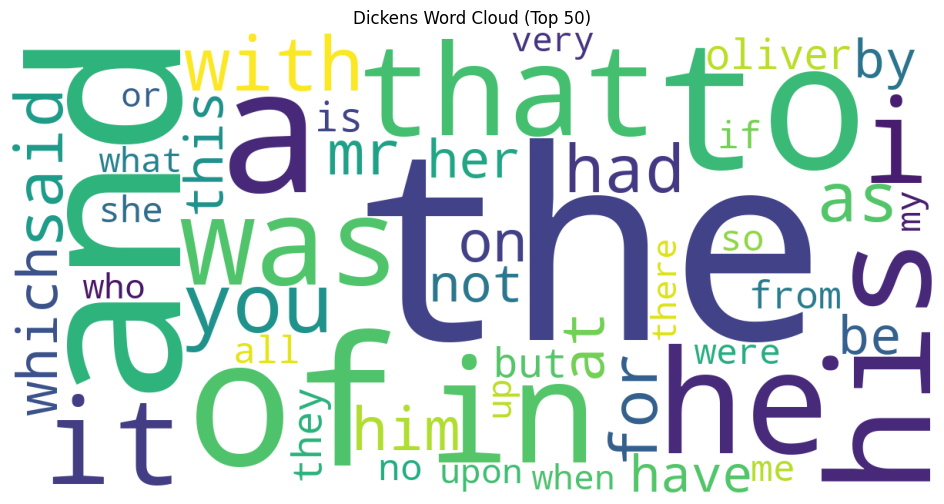

In [ ]:

# Use existing top words and frequencies
freq_map = dict(zip(words, frequencies))

wc = WordCloud(width=1200, height=600, background_color="white",
               stopwords=STOPWORDS, collocations=False)
wc.generate_from_frequencies(freq_map)

plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.axis("off")
plt.title("Dickens Word Cloud (Top 50)")
plt.show()

To understand the structure between text, we need to analyse how words are usually grouped. 
For that, we define  **n-grams**:
* A bigram, or 2-gram, is a group of two consecutive words.
* A trigram, or 3-gram, is a group of three consecutive words.
* An n-gram is a group of n consecutive words.

These groupings can help us understand the underlying structure of language within a text.

Let's analyse the text's bigrams: what are the most common sequences of two words?

In [73]:
# Compute bigram frequencies from the Dickens corpus
bigrams = list(zip(dickens_word_list, dickens_word_list[1:]))
bigram_counts = Counter(bigrams)

# Show the top 50 most common bigrams
print("Top 50 most common bigrams:")
for (bigram_word_1, bigram_word_2), bigram_word_count in bigram_counts.most_common(50):
    print(f"  ({bigram_word_1!r}, {bigram_word_2!r}): {bigram_word_count}")

Top 50 most common bigrams:
  ('of', 'the'): 872
  ('in', 'the'): 605
  ('to', 'the'): 470
  ('said', 'the'): 452
  ('he', 'had'): 336
  ('in', 'a'): 327
  ('on', 'the'): 321
  ('mr', 'bumble'): 303
  ('and', 'the'): 298
  ('with', 'a'): 291
  ('it', 'was'): 281
  ('at', 'the'): 266
  ('of', 'his'): 264
  ('the', 'jew'): 261
  ('he', 'was'): 246
  ('the', 'old'): 237
  ('to', 'be'): 233
  ('for', 'the'): 230
  ('with', 'the'): 229
  ('by', 'the'): 223
  ('had', 'been'): 215
  ('said', 'mr'): 206
  ('as', 'he'): 199
  ('from', 'the'): 198
  ('that', 'he'): 191
  ('of', 'a'): 186
  ('in', 'his'): 186
  ('into', 'the'): 184
  ('the', 'girl'): 181
  ('replied', 'the'): 173
  ('my', 'dear'): 166
  ('and', 'a'): 156
  ('upon', 'the'): 154
  ('it', 'is'): 151
  ('the', 'door'): 148
  ('mr', 'brownlow'): 144
  ('the', 'same'): 141
  ('was', 'a'): 138
  ('that', 'the'): 128
  ('as', 'if'): 127
  ('if', 'he'): 123
  ('for', 'a'): 122
  ('the', 'boy'): 122
  ('there', 'was'): 121
  ('have', 'been

We can visualize that in a histogram as well:

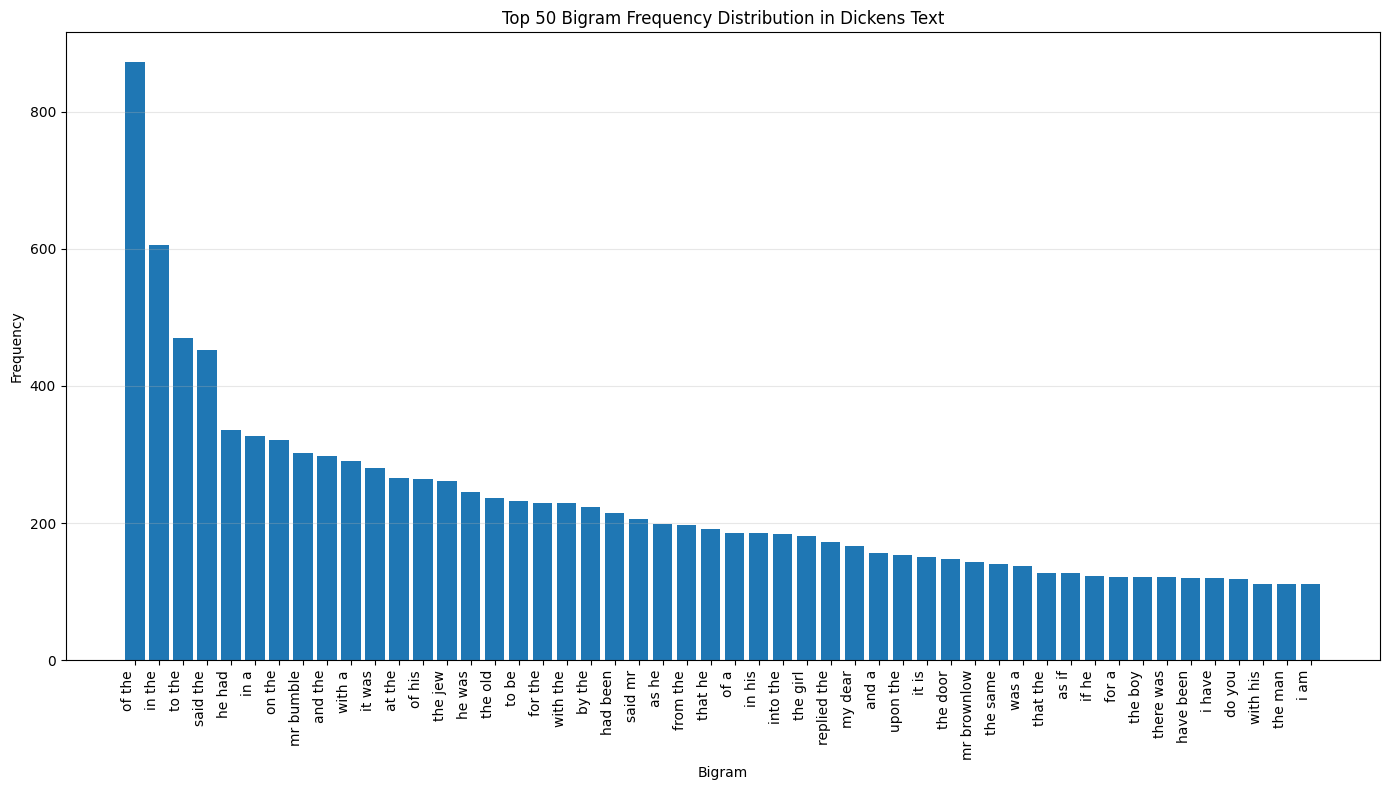

Most frequent bigram: 'of the' appears 872 times
Number of bigrams appearing only once: 62174


In [74]:
# Extract top 20 bigrams for visualization
top_n_bigrams = 50
top_bigrams = bigram_counts.most_common(top_n_bigrams)
bigram_labels = [f"{w1} {w2}" for (w1, w2), count in top_bigrams]
bigram_freqs = [count for (w1, w2), count in top_bigrams]

plt.figure(figsize=(14, 8))
plt.bar(range(len(bigram_freqs)), bigram_freqs)
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.title(f'Top {top_n_bigrams} Bigram Frequency Distribution in Dickens Text')
plt.xticks(range(len(bigram_labels)), bigram_labels, rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Most frequent bigram: '{bigram_counts.most_common(1)[0][0][0]} {bigram_counts.most_common(1)[0][0][1]}' appears {bigram_counts.most_common(1)[0][1]} times")
print(f"Number of bigrams appearing only once: {sum(1 for count in bigram_counts.values() if count == 1)}")

We've analyzed both individual words and bigrams in the Dickens text. Now let's compare their frequency distributions as well as some statistics to understand how they differ.

In [78]:
most_common_words, most_common_word_count = word_counts.most_common(1)[0]
(most_common_word_1, most_common_word_2), most_common_bigram_count = bigram_counts.most_common(1)[0]

print("\n📊 Comparison:")
print(f"  Most common word: '{most_common_words}' ({most_common_word_count} times)")
print(f"  Most common bigram: '{most_common_word_1} {most_common_word_2}' ({most_common_bigram_count} times)")
print(f"  Total unique words: {len(word_counts)}")
print(f"  Total unique bigrams: {len(bigram_counts)}")
print(f"  Bigram/Word ratio: {len(bigram_counts)/len(word_counts):.2f}x more bigrams than words")



📊 Comparison:
  Most common word: 'the' (9584 times)
  Most common bigram: 'of the' (872 times)
  Total unique words: 13211
  Total unique bigrams: 80043
  Bigram/Word ratio: 6.06x more bigrams than words


Looking at the statistics and the two frequency histograms reveals interesting patterns:

**Vocabulary Size**: There are typically many more unique bigrams than unique words. This is because there are exponentially more ways to combine words into pairs than there are individual words.

**Frequency**: The most common word appears far more frequently than the most common bigram. This makes sense, since individual words like "the" or "of" can be used in many different contexts, while specific two-word combinations are naturally more restricted.

**Histogram Shape**: Both histograms follow a similar pattern. Notice how both curves drop steeply at first (on the log scale), then gradually level off. This means a few words/bigrams dominate, while most appear relatively rarely (which shows as a "long tail").



### **Section 1. Summary**

We have successfully analysed a whole book!

We have new insights on:
* **Vocabulary size**, or how many different words there are in the text
* The text's **most used words**
* The definition of an **n-gram**, or a squence of n words
* How the **frequencies of words** and the **frequencies of bigrams** compare

---

## 2. Analysing Audio 🎵

During the previous notebook we learnt about the MIDI protocol. We successfully encoded a melody into numbers, and were able to decode that series of numbers into the original melody (and listen to it!).

However, you might thinking that doesn't sound like the music you usually listen to, and you would be right. Most of the times, we are reproducing an audio file. How does that work? The music stored in a digital device is a **digital audio signal**.

### Digital audio signals

#### Waveforms

In essence, sound is simply air vibrating. An audio signal, then, **represents the fluctuation in air pressure caused by the vibration as a function of time**.

We can graphically represent the change in air pressure caused by a vibration at a certain point in time using a pressure-time plot. This is more commonly known as a **waveform**, and you've probably seen one before:

<img src="https://media.wired.com/photos/65e8385a7e55097b1dfa6ac1/master/w_1600%2Cc_limit/iStock-500703366.jpg" width="400px"/>

Let's load up some audio files. We'll use the `librosa` library to do this.

In [ ]:
djembe_path = os.path.join("media", "187651__owl__djembe-loop-89-bpm.wav")

In [29]:
y_djembe, sr_djembe = librosa.load(djembe_path, duration=10, sr=24000)
ipd.Audio(y_djembe, rate=sr_djembe)

We can produce a waveform for an audio signal directly in Python by plotting the signal information.

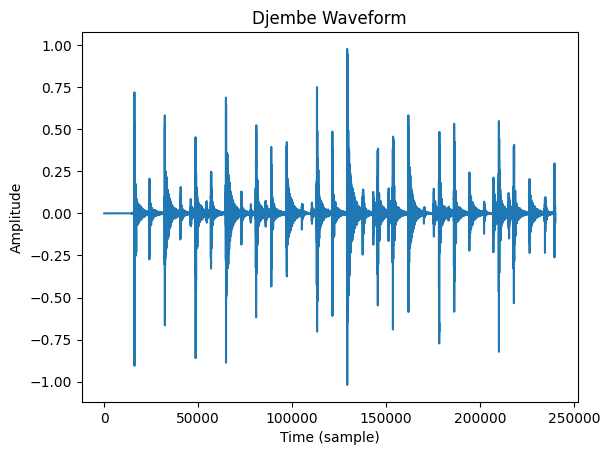

In [30]:
plt.plot(y_djembe)
plt.gca().set(xlabel="Time (sample)", ylabel="Amplitude")
plt.title("Djembe Waveform")
plt.show()

Notice how there are strong *peaks* in this graph. Try listening to the audio again, and think about what those peaks represent.


#### Sample Rate 🔢


When working with digital audio the information is once more a sequence of numbers. In this case, we have a new value for the waveform at regular intervals of time. Each one of these data points is called a **sample**!

<img src="https://jvbalen.github.io/figs/rick.gif" alt="Zooming into an audio file" width="500px"/>

Let's check the values of the first 10 samples of the audio file:

In [35]:
print(y_djembe[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


How often we have a new sample is determined by the **sample rate** (sometimes abbreviated as `sr`). The **sample rate** is measured in Hertz (Hz), and represents how many samples we have in one second. It is also the inverse of the time interval between two consecutive samples.

<img src="https://www.hollyland.com/wp-content/uploads/2023/11/image-563.png" alt="Comparison between low and high sample rates" width="500px"/>


Let's print out the sample rate of our audio:

In [77]:
print(sr_djembe)

24000


Standard sample rates you might encounter include:
- 44100 Hz (44.1 kHz): the standard sample rate for **CD-quality** audio
- 48000 Hz (48 kHz): the standard sample rate for **DVD-quality** audio.
- 96000 Hz (96 kHz): double the rate of 48 kHz, common in **high-resolution audio** but rarer in everyday listening.
- 22050 Hz: half the rate of CD-quality audio. Common in machine learning contexts.

Note that humans cannot easily hear the difference between 48 and 44.1 kHz sampling rates. One benefit of the lower value is that audio encoded as 44.1 kHz usually has a **smaller file size**, simply because it has fewer samples per second.

### Time Domain Audio Features

Now, what kind of statistical information can we get from an audio signal? We call these measurable characteristics of sound **audio features**, and we'll cover some interesting examples ahead.

#### Root Mean Square (RMS)
Root Mean Square (RMS) measures the average power or loudness of a signal over time. 


$${RMS} = \sqrt{\frac{1}{N}\sum_{n=1}^{N} x_n^2}$$

where

$x_n$ is the $n$-th sample of the audio signal

$N$ is the total number of samples in the signal

Let's take a look of what that feature looks like for out Djembe recording:

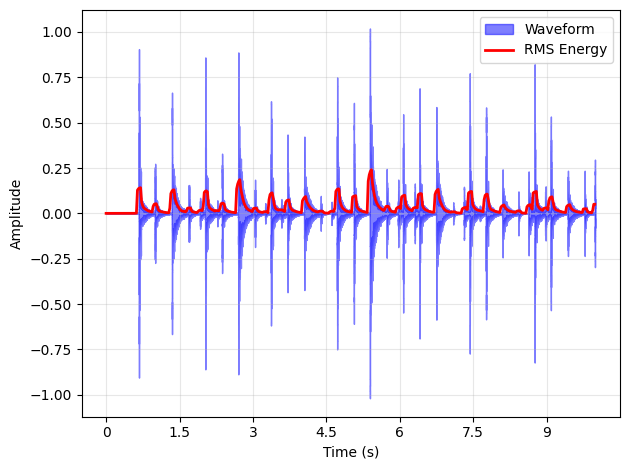

In [47]:
# Calculate RMS energy
rms = librosa.feature.rms(y=y_djembe, frame_length=2048, hop_length=512)

# Plot waveform using librosa.display
librosa.display.waveshow(y_djembe, sr=sr_djembe, alpha=0.5, label='Waveform', color='blue')

# Plot RMS energy overlay
frames = range(len(rms[0]))
times_rms = librosa.frames_to_time(frames, sr=sr_djembe, hop_length=512)
plt.plot(times_rms, rms[0], color='red', linewidth=2, label='RMS Energy')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Let's compare that to another audio signal, this time, a whistle.

In [36]:
whistle_path = os.path.join("media", "197976__macsounds1__whistle-project-5.wav")
y_whistle, sr_whistle = librosa.load(whistle_path, duration=10, sr=24000)
ipd.Audio(y_whistle, rate=sr_whistle)

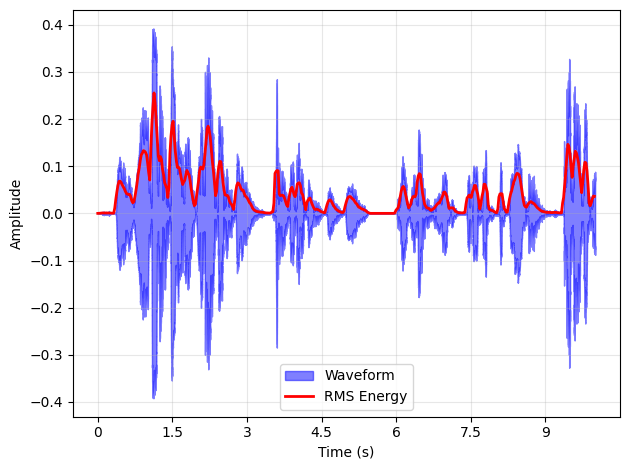

In [46]:
# Calculate RMS energy

rms = librosa.feature.rms(y=y_whistle, frame_length=2048, hop_length=512)

# Plot waveform using librosa.display
librosa.display.waveshow(y_whistle, sr=sr_whistle, alpha=0.5, label='Waveform', color='blue')

# Plot RMS energy overlay
frames = range(len(rms[0]))
times_rms = librosa.frames_to_time(frames, sr=sr_whistle, hop_length=512)
plt.plot(times_rms, rms[0], color='red', linewidth=2, label='RMS Energy')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

If we listen to the two recordings we immediately know which one is a Djembe and which one is the Whistle. Are any of the differences between those two sounds reflected when comparing the two RMS plots?

#### Zero Crossing Rate (ZCR)

Another interesting audio feature is the Zero Crossing Rate, which, as its name says, measures how many times the signal crosses zero (that is, changes sign!) in a given time frame.

$${ZCR} = \frac{1}{(N-1)}\sum_{n=1}^{N-1} \left| \operatorname{sgn}(x_{n+1}) - \operatorname{sgn}(x_n) \right|$$

where
$$
\operatorname{sgn}(x) =
\begin{cases}
+1, & x > 0, \\
0,  & x = 0, \\
-1, & x < 0.
\end{cases}
$$

Let's see what the Zero Crossing Rate looks like for our two sounds:

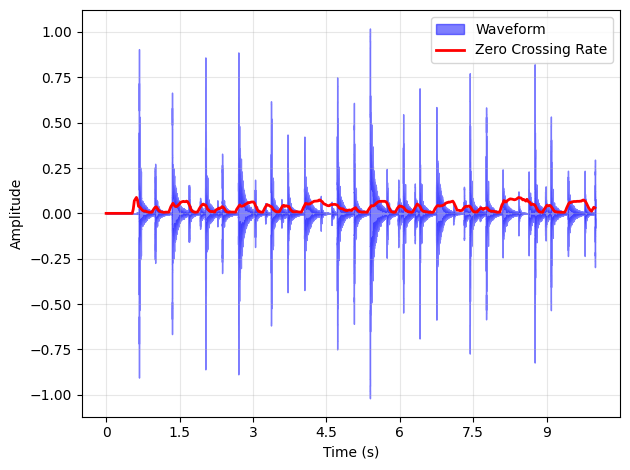

In [49]:
# Calculate Zero Crossing Rate
zcr = librosa.feature.zero_crossing_rate(y=y_djembe, frame_length=2048, hop_length=512)

# Plot waveform using librosa.display
librosa.display.waveshow(y_djembe, sr=sr_djembe, alpha=0.5, label='Waveform', color='blue')

# Plot ZCR overlay
frames = range(len(zcr[0]))
times_zcr = librosa.frames_to_time(frames, sr=sr_djembe, hop_length=512)
plt.plot(times_zcr, zcr[0], color='red', linewidth=2, label='Zero Crossing Rate')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

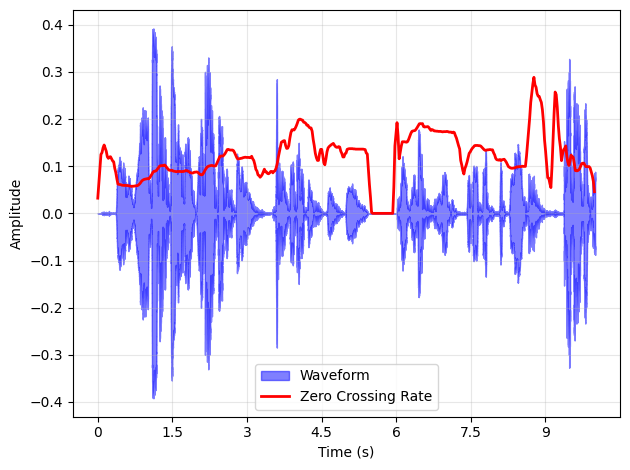

In [50]:
# Calculate Zero Crossing Rate
zcr = librosa.feature.zero_crossing_rate(y=y_whistle, frame_length=2048, hop_length=512)

# Plot waveform using librosa.display
librosa.display.waveshow(y_whistle, sr=sr_whistle, alpha=0.5, label='Waveform', color='blue')

# Plot ZCR overlay
frames = range(len(zcr[0]))
times_zcr = librosa.frames_to_time(frames, sr=sr_whistle, hop_length=512)
plt.plot(times_zcr, zcr[0], color='red', linewidth=2, label='Zero Crossing Rate')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

GET A BETTER WHISTLE SOUND SO WE CAN SEE PITCH VARIATION

### Using Spectrograms 📢

Another useful way of representing audio for machine learning is using a **spectrogram**.

We can think of spectrograms as a 3D map of the audio signal, showing the amount of energy (coded in height values), for each:
* Frequency value (Hz), which is related to pitch. The lowest the frequency, the lowest the sound is pitched.
* Moment of time (s)


<img src="https://www.researchgate.net/publication/347874331/figure/fig3/AS:974591413477377@1609372108329/Working-of-a-Spectrogram-24-3D-Visualization-of-a-Spectrogram.jpg" width="700px"/>


For practical reasons, we usually represent these maps in 2D:

<img src="https://upload.wikimedia.org/wikipedia/commons/c/c5/Spectrogram-19thC.png" width="700px"/>

* In the horizontal axis we see time passing
* In the vertical axis we have different frequencies
* The colour represent the energy. The brighter a region is, the more energy we have for that frequency at that time!

Now let's look at the spectrogram of our audio files!
Let's start with the whistle:

In [119]:
def calculate_spectrogram(y):
    X_stft = librosa.stft(y, win_length=512, hop_length=256)
    spect = librosa.amplitude_to_db(np.abs(X_stft))
    return X_stft, spect

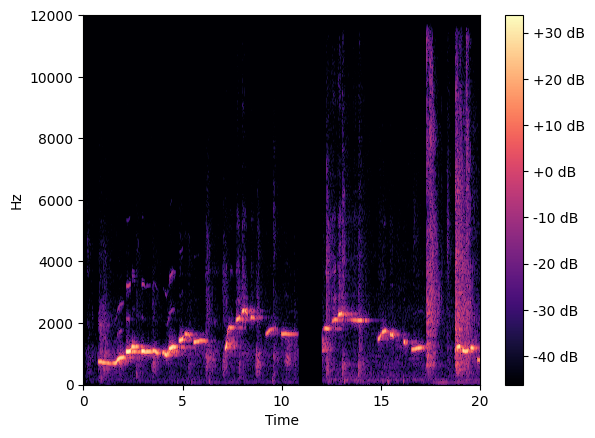

In [120]:
_, spect = calculate_spectrogram(y_whistle)
librosa.display.specshow(spect, sr=sr_whistle, x_axis="time", y_axis="linear")
plt.colorbar(format="%+2.0f dB")
plt.show()

Let's try to look at it and interpret what is happening. Now listen to the audio again while looking at the spectrogram. What does that bright line in the graph represent? What does it relate to?

In [83]:
ipd.Audio(y_whistle, rate=sr_whistle)

Let's see what happens for our Djembe signal:

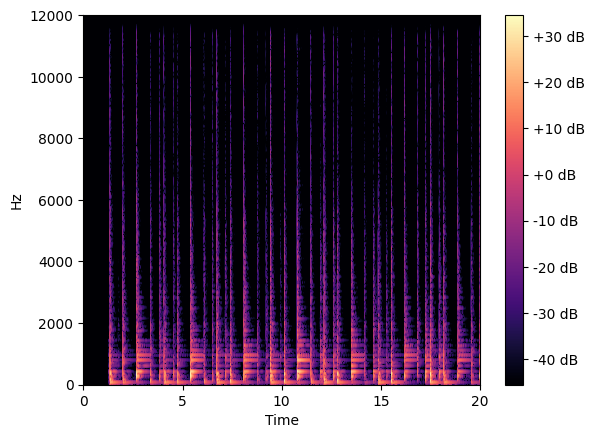

In [127]:
_, spect = calculate_spectrogram(y_djembe)
librosa.display.specshow(spect, sr=sr_djembe, x_axis="time", y_axis="linear")
plt.colorbar(format="%+2.0f dB")
plt.show()

Let's listen while looking at the spectrogram. What do those vertical lines represent?

In [128]:
ipd.Audio(y_djembe, rate=sr_djembe)

### Frequency Domain Audio Features 🎼

Now we'll explore some **audio features** that are based on the spectrogram's information, therefore, we can say they analyse frequency domain information.

#### Spectral Centroid ⭕

You might not have heard the term spectral centroid before, but the idea behind it is pretty simple. For each *column* in the spectrogram (each moment in time), we find the average frequency where most of the sound's energy is concentrated.

In other words, let $x^j$ be the vector corresponding with column $j$ of a spectrogram. We then calculate the spectral centroid $SC$ at $j$ as:

$$
SC_j = \frac{1}{n} \sum_{i=1}^{n} x_i^j
$$

where $n$ is the number of frequency bins in that column.

This gives the centroid for a single moment. Since a sound changes over time, we can calculate the centroid for **every column** in the spectrogram. This produces a sequence of values showing how the "center of energy" moves through the frequencies as the sound plays:

$$
\mathbf{SC} =
\begin{bmatrix}
SC_1 \\
SC_2 \\
\vdots \\
SC_m
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{n} \sum_{i=1}^{n} x_i^1 \\[1em]
\frac{1}{n} \sum_{i=1}^{n} x_i^2 \\[0.5em]
\vdots \\[0.5em]
\frac{1}{n} \sum_{i=1}^{n} x_i^m
\end{bmatrix}
\in \mathbb{R}^m
$$

where $m$ is the total number of columns in the spectrogram.

The vector $\mathbf{SC}$ is one-dimensional and varies over time. You can think of it as a simple line that tracks whether the sound is mostly low-pitched or high-pitched at each moment. It provides a compact way to summarize the "brightness" of a sound without examining the entire spectrogram.

Let's plot the spectral centroid of our signal.

c:\Users\jimea\OneDrive\Documents\QMUL\Work\epsrc-ai-pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


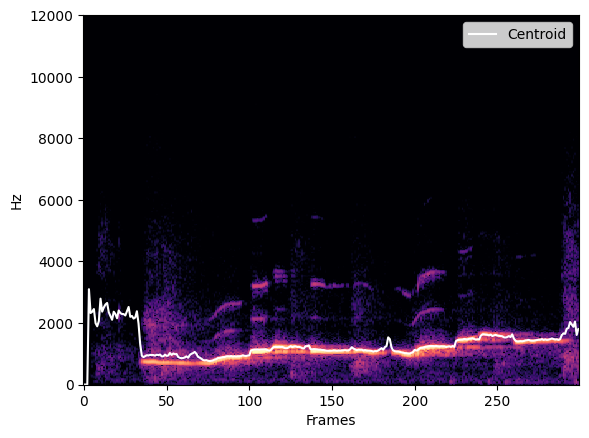

In [129]:
X_stft, spect = calculate_spectrogram(y_whistle)
cent = librosa.feature.spectral_centroid(S=np.abs(X_stft), sr=sr_whistle, win_length=512, hop_length=256)
librosa.display.specshow(spect[:, :300], sr=sr_whistle, x_axis="frames", y_axis="linear")
plt.plot(cent[0, :300], label="Centroid", color="white")
plt.legend()
plt.show()

c:\Users\jimea\OneDrive\Documents\QMUL\Work\epsrc-ai-pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


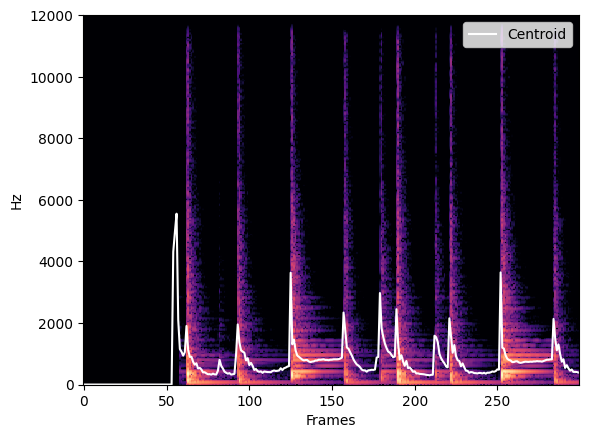

In [130]:
X_stft, spect = calculate_spectrogram(y_djembe)
cent = librosa.feature.spectral_centroid(S=np.abs(X_stft), sr=sr_djembe, win_length=512, hop_length=256)
librosa.display.specshow(spect[:, :300], sr=sr_djembe, x_axis="frames", y_axis="linear")
plt.plot(cent[0, :300], label="Centroid", color="white")
plt.legend()
plt.show()

Take a listen to the audio file again while looking at the plot.

#### Spectral Bandwidth 🔀

Just as our **spectral centroid** is equivalent to the *average frequency* for every column in our spectrogram, we can also consider the **standard deviation** of every column. We call this feature the **spectral bandwidth**.

Let $x^j$ be the vector corresponding to column $j$ of the spectrogram. The spectral bandwidth at time $j$ is:

$$
SB_j = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(x_i^j - SC_j\right)^2}
$$

where $SC_j$ is the spectral centroid for column $j$ and $n$ is the number of frequency bins.

> Recall that $SC_j$ is simply the mean of $x^j$

By computing this for **every column**, we get a sequence of values showing how the frequency spread changes over time:

$$
\mathbf{SB} =
\begin{bmatrix}
SB_1 \\
SB_2 \\
\vdots \\
SB_m
\end{bmatrix}
\in \mathbb{R}^m
$$

The vector $\mathbf{SB}$ is also one-dimensional. It tells us whether the sound is concentrated around a narrow range of frequencies or spread out over a wide range at each moment.

Let's calculate the spectral bandwidth for our signal.

c:\Users\jimea\OneDrive\Documents\QMUL\Work\epsrc-ai-pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


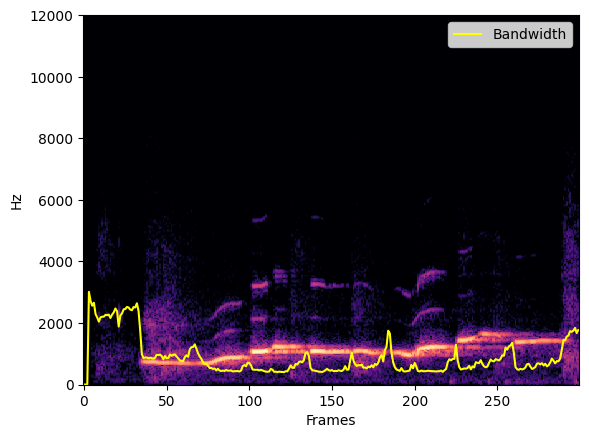

In [131]:
X_stft, spect = calculate_spectrogram(y_whistle)
bw = librosa.feature.spectral_bandwidth(S=np.abs(X_stft), sr=sr_whistle, win_length=512, hop_length=256)
librosa.display.specshow(spect[:, :300], sr=sr_whistle, x_axis="frames", y_axis="linear")
plt.plot(bw[0, :300], label="Bandwidth", color="yellow")
plt.legend()
plt.show()

c:\Users\jimea\OneDrive\Documents\QMUL\Work\epsrc-ai-pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


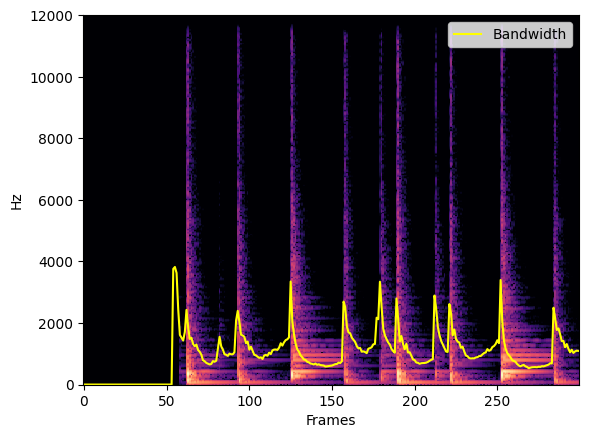

In [132]:
X_stft, spect = calculate_spectrogram(y_djembe)
bw = librosa.feature.spectral_bandwidth(S=np.abs(X_stft), sr=sr_djembe, win_length=512, hop_length=256)
librosa.display.specshow(spect[:, :300], sr=sr_djembe, x_axis="frames", y_axis="linear")
plt.plot(bw[0, :300], label="Bandwidth", color="yellow")
plt.legend()
plt.show()

Take another listen to the audio file while looking at the spectral bandwidth plot.

#### More Features 📂

There are **many more features** that we could extract from a spectrogram or waveform. From your own knowledge of mathematics and statistics, *can you think of any other features we might be able to extract?*

For more information on the features that can be extracted from an audio signal with `librosa`, check out [the documentation.](https://librosa.org/doc/latest/feature.html)

### **Section 2. Summary**



## 3. Analysing Images 🖼

When we work with images in machine learning contexts, we have to think about how to represent many different qualities:
- height and width
- colour
- resolution
- scale

Let's load an image in Python to show what we mean. We'll use the `skimage` library.


In [133]:
astronaut = skimage.data.astronaut()
print(astronaut.shape)

(512, 512, 3)


If we inspect the image, we can see that we have a 3 dimensional array.
- The first dimension (512) shows the number of rows, which correspond to the image's height in pixels.
- The second dimension (512) represents the number of columns, or the image's width in pixels.
- The third dimension (3) corresponds to the colour channels: Red, Green, and Blue (RGB).

So this image is a **512 x 512 pixel color image**, where each pixel has three values representing the intensity of red, green, and blue. Let's show the image:


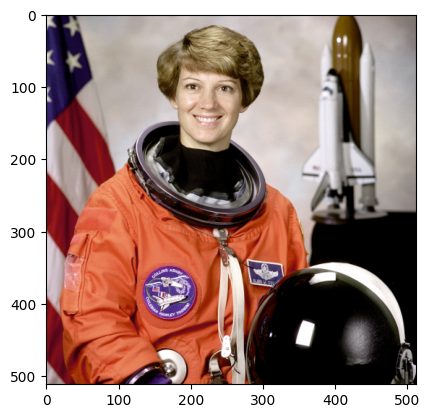

In [134]:
plt.imshow(astronaut)
plt.show()

(427, 640, 3)


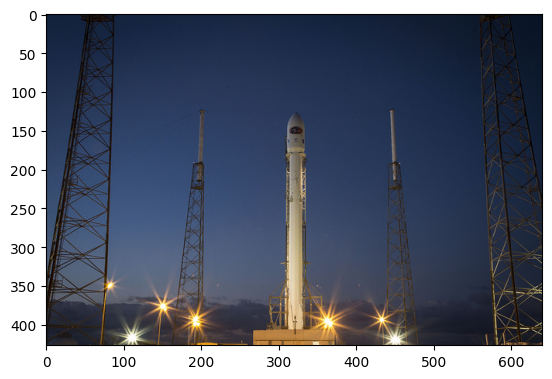

In [180]:
rocket = skimage.data.rocket()
print(rocket.shape)
plt.imshow(rocket)
plt.show()

### Feature Extraction

When we were working with audio signals, it often made sense to extract features as **one-dimensional sequences**, where each point corresponded to a frame in a spectrogram. This worked because sound changes over time, and we could describe how certain properties - like brightness or pitch - evolved from moment to moment.

When working with images, this idea **doesn't quite apply** in the same way. Unlike audio, an image has no concept of time - it's a single snapshot rather than a sequence of events. One column of pixels doesn't "occur" before or after another; instead, every pixel exists simultaneously in two spatial dimensions.


Because of this, we usually extract **spatial features** from images instead of temporal ones. These features describe what the image looks like in terms of **colour, texture, edges, or shapes,** rather than how something changes over time.


#### Grayscale ⬛

Notice how our colour image is three-dimensional: we have separate values for every pixel showing the amount of red, green, and blue within the image.

Sometimes in machine learning, we may not need to pass this information to the model. For instance, in object detection, we might only be interested in the *shapes and contours* of the objects in the image, and *not their colour*. Instead, we can convert our image to grayscale (or black-and-white).

We can use `skimage` to do this for us:

In [183]:
astronaut_gray = skimage.color.rgb2gray(astronaut)
print(astronaut_gray.shape)

(512, 512)


Notice how we've lost the third dimension of our array (sometimes called the *"channel dimension"*). Now we have a two-dimensional image, reprented as a 512 x 512 grid. Every value in this grid corresponds to the grayscale value of that pixel. Values of 0 are black; as this number increases, *more and more white* is added.

Let's show the transformed image:

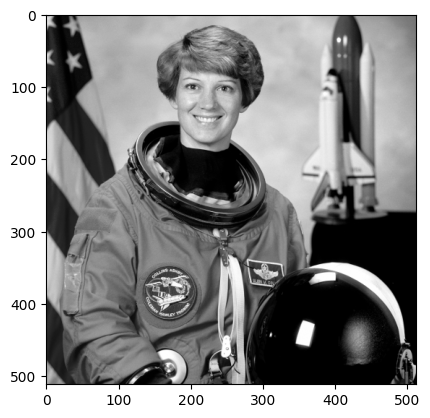

In [184]:
plt.imshow(astronaut_gray, cmap=plt.cm.gray)
plt.show()

(427, 640)


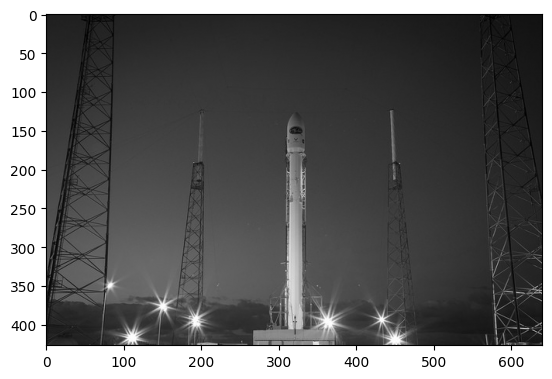

In [185]:
rocket_gray = skimage.color.rgb2gray(rocket)
print(rocket_gray.shape)
plt.imshow(rocket_gray, cmap=plt.cm.gray)
plt.show()

### Pixel Intensity Histogram

WHAT IT IS

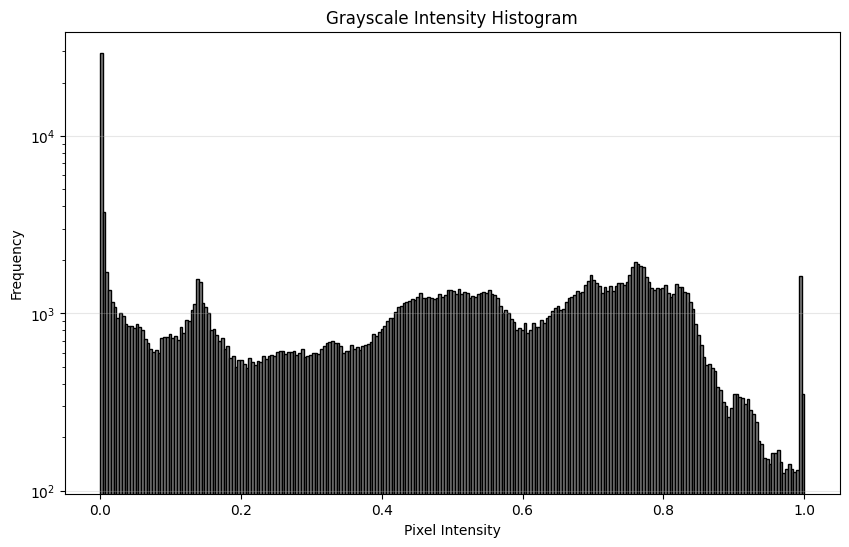

In [186]:
plt.figure(figsize=(10, 6))
plt.hist(astronaut_gray.flatten(), bins=256, range=(0, 1), color='gray', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Grayscale Intensity Histogram')
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

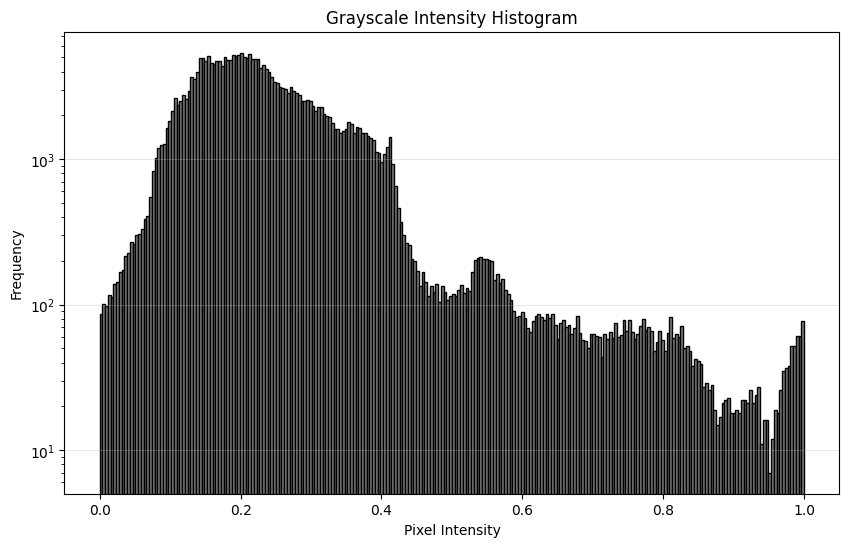

In [187]:
plt.figure(figsize=(10, 6))
plt.hist(rocket_gray.flatten(), bins=256, range=(0, 1), color='gray', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Grayscale Intensity Histogram')
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

COMPARISONS

#### Colour Histogram

HEY! IT'S IN COLOUR

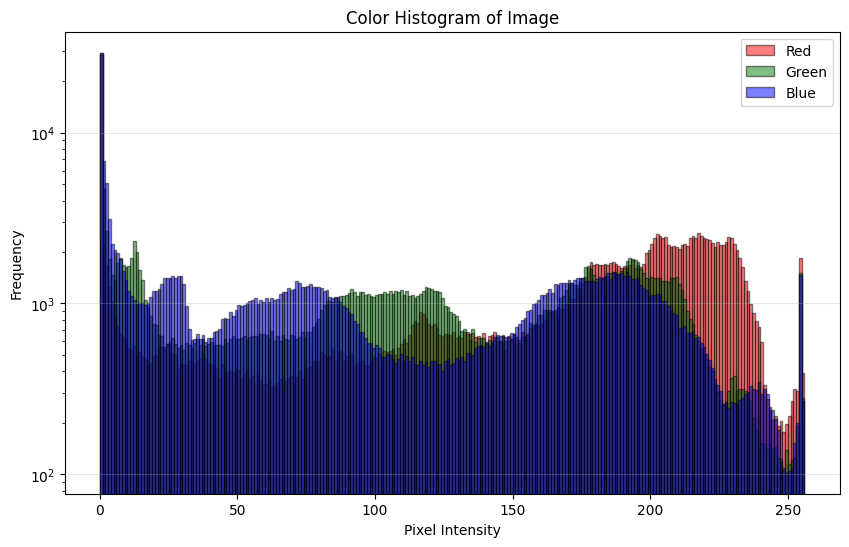

In [ ]:
plt.figure(figsize=(10, 6))

# Extract each color channel
red = astronaut[:, :, 0].flatten()
green = astronaut[:, :, 1].flatten()
blue = astronaut[:, :, 2].flatten()

# Plot histograms for each channel
plt.hist(red, bins=256, range=(0, 256), alpha=0.5, label='Red', color='red', edgecolor='black')
plt.hist(green, bins=256, range=(0, 256), alpha=0.5, label='Green', color='green', edgecolor='black')
plt.hist(blue, bins=256, range=(0, 256), alpha=0.5, label='Blue', color='blue', edgecolor='black')

plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Color Histogram of Image')
plt.legend()
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

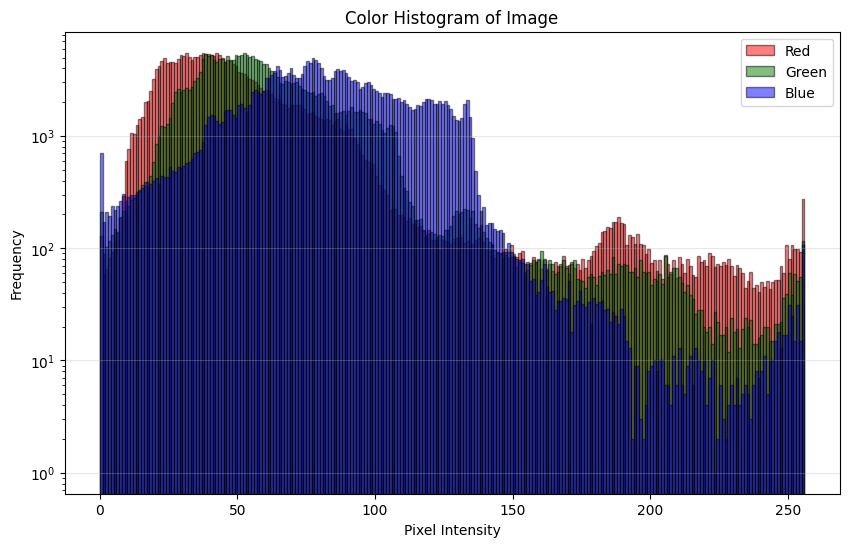

In [ ]:
plt.figure(figsize=(10, 6))

# Extract each color channel
red = rocket[:, :, 0].flatten()
green = rocket[:, :, 1].flatten()
blue = rocket[:, :, 2].flatten()

# Plot histograms for each channel
plt.hist(red, bins=256, range=(0, 256), alpha=0.5, label='Red', color='red', edgecolor='black')
plt.hist(green, bins=256, range=(0, 256), alpha=0.5, label='Green', color='green', edgecolor='black')
plt.hist(blue, bins=256, range=(0, 256), alpha=0.5, label='Blue', color='blue', edgecolor='black')

plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Color Histogram of Image')
plt.legend()
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

COMPARISON

#### Edge detection

SOME TEXT

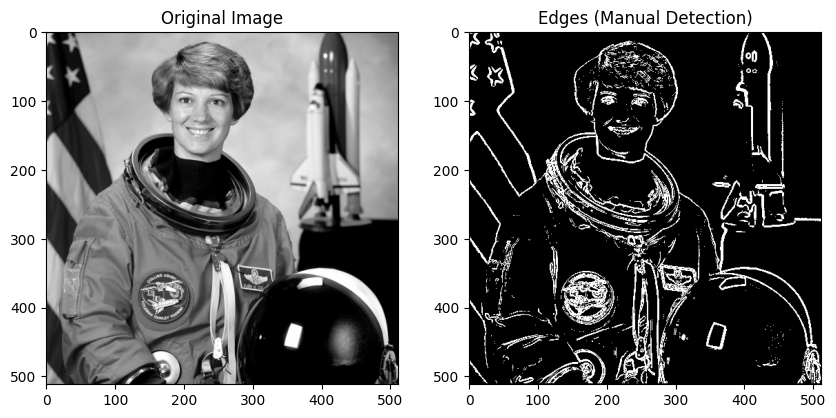

In [189]:
# Manual edge detection by comparing neighboring pixels
# Get the dimensions of the image
height = astronaut_gray.shape[0]
width = astronaut_gray.shape[1]

# Create an empty array to store the edges
edges = np.zeros((height, width))

# Set a threshold - if the difference between pixels is greater than this, it's an edge
threshold = 0.15

# Loop through each pixel (except the edges of the image)
for row in range(1, height - 1):
    for col in range(1, width - 1):
        # Get the current pixel value
        current_pixel = astronaut_gray[row, col]
        
        # Get the neighboring pixel values
        left_pixel = astronaut_gray[row, col - 1]
        right_pixel = astronaut_gray[row, col + 1]
        top_pixel = astronaut_gray[row - 1, col]
        bottom_pixel = astronaut_gray[row + 1, col]
        
        # Calculate the differences
        horizontal_diff = abs(right_pixel - left_pixel)
        vertical_diff = abs(bottom_pixel - top_pixel)
        
        # If either difference is large enough, mark it as an edge
        if horizontal_diff > threshold or vertical_diff > threshold:
            edges[row, col] = 1  # Mark as edge (white)
        else:
            edges[row, col] = 0  # Not an edge (black)

# Display the results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(astronaut_gray, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Edges (Manual Detection)")
plt.show()

Edge detection with skimage

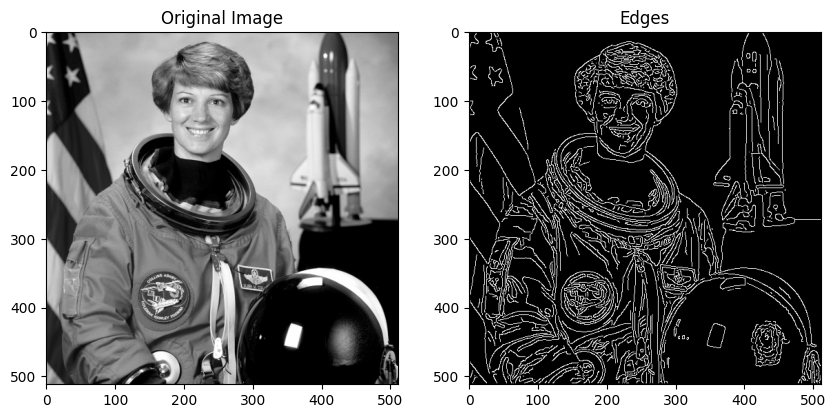

In [142]:
edges = skimage.feature.canny(astronaut_gray)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(astronaut_gray, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Edges")
plt.show()

Notice how the extracted edges maintain much of the details of the image in the foreground (e.g., the rocket ship and flag), but miss out details in the background (e.g., the wallpaper). Extracting the edges of an image can be useful for tasks like **object detection**, where we want to only focus on the most important parts of the image.

We can also consider the **edge density**: the proportion of pixels in the image that lie along an edge

#### More Features 📂

Just as with audio, there are many different kinds of spatial features we can extract from an image. For more details, check out [the documentation from `skimage`.](https://scikit-image.org/docs/0.25.x/api/skimage.feature.html)

### **Section 3. Summary**


---
## Conclusion

FILL OUT

